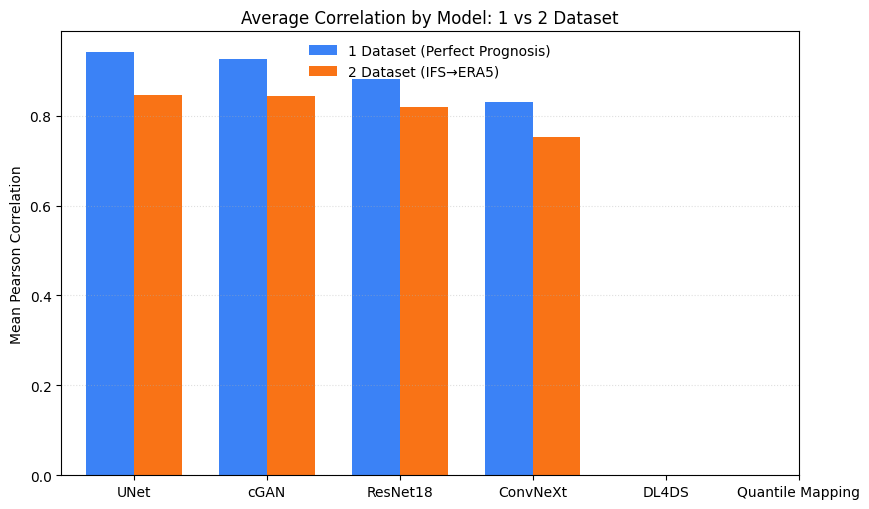

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load metrics CSV ---
csv_path = os.path.join(
    r"c:\Users\zharif\Documents\Dataset TA\climate-research-workbench\notebooks\evaluation",
    "parsed_notebook_metrics.csv",
)
df = pd.read_csv(csv_path)

# --- Fix misaligned rows (missing scenario column) ---
expected_preupsample = {"preupsample", "no-preupsample"}
expected_dataset = {"1 dataset", "2 dataset"}
model_names = {"UNet", "cGAN", "ResNet18", "ConvNeXt", "DL4DS", "Quantile Mapping", "Unet", "GAN"}

def _infer_scenario(run_path):
    if isinstance(run_path, str):
        if run_path.startswith("scenario1"):
            return "scenario1"
        if run_path.startswith("scenario2"):
            return "scenario2"
    return "unknown"

misaligned = (
    df["scenario"].isin(expected_preupsample)
    & df["preupsample"].isin(expected_dataset)
    & df["dataset"].isin(model_names)
)
if misaligned.any():
    shifted = df.loc[misaligned, [
        "scenario", "preupsample", "dataset", "model", "loss_function",
        "variable", "rmse", "mae", "bias", "corr", "baseline_rmse", "skill",
]].copy()
    df.loc[misaligned, "scenario"] = df.loc[misaligned, "run_path"].apply(_infer_scenario)
    df.loc[misaligned, "preupsample"] = shifted["scenario"]
    df.loc[misaligned, "dataset"] = shifted["preupsample"]
    df.loc[misaligned, "model"] = shifted["dataset"]
    df.loc[misaligned, "loss_function"] = shifted["model"]
    df.loc[misaligned, "variable"] = shifted["loss_function"]
    df.loc[misaligned, "rmse"] = shifted["variable"]
    df.loc[misaligned, "mae"] = shifted["rmse"]
    df.loc[misaligned, "bias"] = shifted["mae"]
    df.loc[misaligned, "corr"] = shifted["bias"]
    df.loc[misaligned, "baseline_rmse"] = shifted["corr"]
    df.loc[misaligned, "skill"] = shifted["baseline_rmse"]

# --- Clean and filter ---
df["model"] = df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})
df = df[df["dataset"].isin(["1 dataset", "2 dataset"])]
df = df[df["variable"].isin(["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"])]

# Average correlation across the four variables
mean_corr = (
    df.groupby(["model", "dataset"], as_index=False)["corr"]
      .mean()
      .pivot(index="model", columns="dataset", values="corr")
)

# Ensure consistent model order
model_order = ["UNet", "cGAN", "ResNet18", "ConvNeXt", "DL4DS", "Quantile Mapping"]
mean_corr = mean_corr.reindex(model_order)

# --- Plot: grouped bar chart ---
x = np.arange(len(mean_corr.index))
width = 0.36

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.bar(x - width / 2, mean_corr["1 dataset"], width, label="1 Dataset (Perfect Prognosis)", color="#3b82f6")
ax.bar(x + width / 2, mean_corr["2 dataset"], width, label="2 Dataset (IFS→ERA5)", color="#f97316")

ax.set_xticks(x)
ax.set_xticklabels(mean_corr.index)
ax.set_ylabel("Mean Pearson Correlation")
ax.set_title("Average Correlation by Model: 1 vs 2 Dataset")
ax.grid(axis="y", linestyle=":", alpha=0.4)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [2]:
# --- Inspect summary: preupsample + 2 dataset (including DL4DS and QM) ---
# DL4DS and Quantile Mapping have preupsample="no-preupsample", so include via OR
_dl4ds_qm_models = {"DL4DS", "Quantile Mapping"}
inspect_df = df[
    (
        (df["preupsample"] == "preupsample") |
        (df["model"].isin(_dl4ds_qm_models))
    ) &
    (df["dataset"] == "2 dataset") &
    (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
]
if inspect_df.empty:
    raise ValueError("No rows for preupsample + 2 dataset in parsed_notebook_metrics.csv")

summary = (
    inspect_df.groupby(["variable", "model"], as_index=False)
              .agg(
                  rmse_mean=("rmse", "mean"), rmse_std=("rmse", "std"),
                  mae_mean=("mae", "mean"),   mae_std=("mae", "std"),
                  corr_mean=("corr", "mean"), corr_std=("corr", "std"),
              )
)

def _fmt(mean, std, prec=4):
    if np.isnan(std):
        std = 0.0
    return f"{mean:.{prec}f} \u00b1 {std:.4g}"

summary["RMSE"] = summary.apply(lambda r: _fmt(r.rmse_mean, r.rmse_std, 4), axis=1)
summary["MAE"]  = summary.apply(lambda r: _fmt(r.mae_mean, r.mae_std, 4), axis=1)
summary["Pearson Corr"] = summary.apply(lambda r: _fmt(r.corr_mean, r.corr_std, 4), axis=1)

summary = summary[["variable", "model", "RMSE", "MAE", "Pearson Corr"]]

var_order = ["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]
model_order = ["ConvNeXt", "cGAN", "ResNet18", "UNet", "DL4DS", "Quantile Mapping"]
summary["variable"] = pd.Categorical(summary["variable"], categories=var_order, ordered=True)
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values(["variable", "model"]).reset_index(drop=True)
summary

,variable,model,RMSE,MAE,Pearson Corr
0,T2m (K),ConvNeXt,0.7129 ± 7.35e-05,0.5790 ± 6.136e-05,0.8037 ± 1.263e-05
1,T2m (K),cGAN,0.6962 ± 0.0004113,0.5635 ± 0.0003403,0.8201 ± 3.145e-06
2,T2m (K),ResNet18,0.5728 ± 0.0008046,0.4468 ± 0.0005004,0.8308 ± 0.0002416
3,T2m (K),UNet,0.5555 ± 0.00472,0.4329 ± 0.00455,0.8391 ± 0.0005628
4,TP 24hr (mm),ConvNeXt,0.0069 ± 2.52e-07,0.0036 ± 1.412e-07,0.7866 ± 1.059e-05
5,TP 24hr (mm),cGAN,0.0065 ± 1.645e-08,0.0034 ± 2.933e-07,0.8121 ± 2.479e-05
6,TP 24hr (mm),ResNet18,0.0065 ± 1.457e-05,0.0033 ± 3.889e-06,0.8099 ± 0.0003651
7,TP 24hr (mm),UNet,0.0064 ± 5.599e-05,0.0033 ± 1.811e-05,0.8155 ± 0.000867
8,U10 (m/s),ConvNeXt,1.2064 ± 3.094e-05,0.9259 ± 2.545e-05,0.8667 ± 2.868e-06
9,U10 (m/s),cGAN,1.1299 ± 0.0001703,0.8657 ± 0.0001222,0.8810 ± 0.0001259


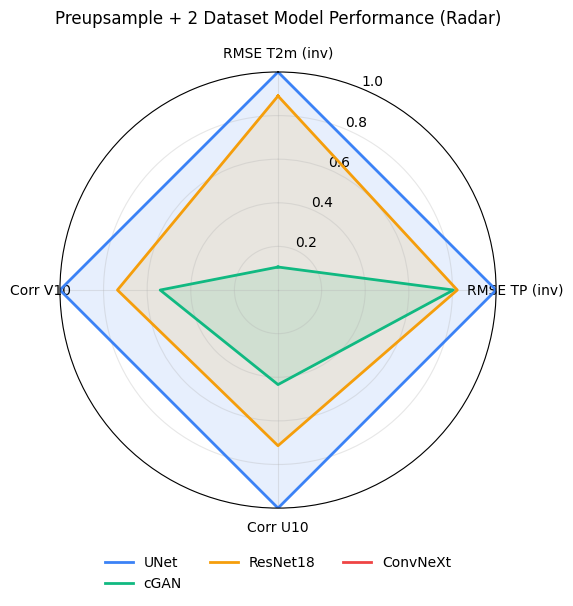

In [3]:
# --- Radar chart: Scenario 4 (preupsample, 2 dataset) ---
# Note: use all rows that match preupsample + 2 dataset.
# DL4DS and Quantile Mapping have preupsample="no-preupsample", so include via OR
_dl4ds_qm_models_radar = {"DL4DS", "Quantile Mapping"}

base_filter = (
    (
        (df["preupsample"] == "preupsample") |
        (df["model"].isin(_dl4ds_qm_models_radar))
    ) &
    (df["dataset"] == "2 dataset") &
    (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
)
radar_df = df[base_filter].copy()

if radar_df.empty:
    raise ValueError(
        "No rows found for preupsample + 2 dataset. "
        "Check parsed_notebook_metrics.csv entries."
    )

radar_df["model"] = radar_df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})

# Aggregate across runs if multiple entries exist
agg = (
    radar_df.groupby(["model", "variable"], as_index=False)
            .mean(numeric_only=True)
)

# Build metrics table
metrics = agg.pivot(index="model", columns="variable", values=["rmse", "corr"])
model_order = ["UNet", "cGAN", "ResNet18", "ConvNeXt", "DL4DS", "Quantile Mapping"]
metrics = metrics.reindex(model_order)

# Normalize: lower RMSE is better -> invert; higher Corr is better
t2m_rmse = metrics[("rmse", "T2m (K)")].values
tp_rmse = metrics[("rmse", "TP 24hr (mm)")].values
u10_corr = metrics[("corr", "U10 (m/s)")].values
v10_corr = metrics[("corr", "V10 (m/s)")].values

def _inv_minmax(x):
    x = np.asarray(x, dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    if np.isclose(x_max, x_min):
        return np.ones_like(x)
    return (x_max - x) / (x_max - x_min)

def _minmax(x):
    x = np.asarray(x, dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)
    if np.isclose(x_max, x_min):
        return np.ones_like(x)
    return (x - x_min) / (x_max - x_min)

scores = np.column_stack([
    _inv_minmax(t2m_rmse),
    _inv_minmax(tp_rmse),
    _minmax(u10_corr),
    _minmax(v10_corr),
])

labels = ["RMSE T2m (inv)", "RMSE TP (inv)", "Corr U10", "Corr V10"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(7.2, 6.2))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

colors = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6", "#ec4899"]
for i, model in enumerate(metrics.index):
    if model not in metrics.index or np.any(np.isnan(scores[i])):
        continue
    vals = scores[i].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, color=colors[i], label=model)
    ax.fill(angles, vals, color=colors[i], alpha=0.12)

ax.set_title("Preupsample + 2 Dataset Model Performance (Radar)", pad=16)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

C:\Users\zharif\AppData\Local\Temp\ipykernel_22620\833322321.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df["model"] = plot_df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})


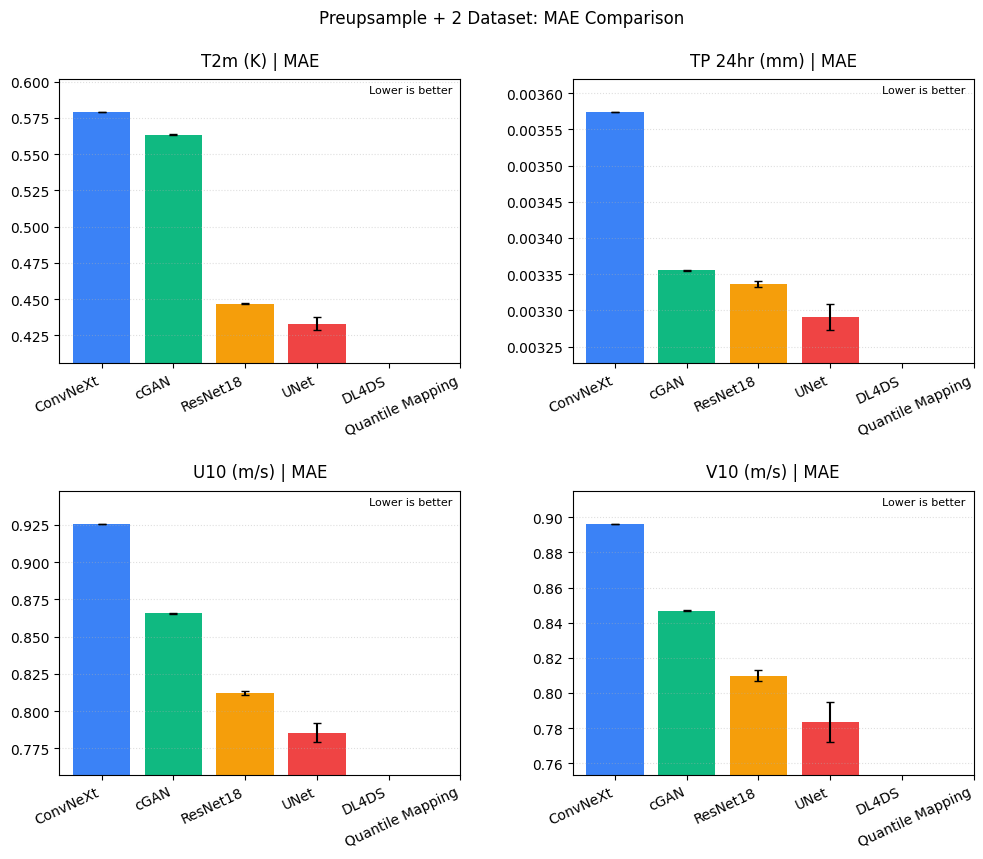

In [4]:
# --- Alternative plot: 2x2 grouped bars with error bars (MAE only) ---
# DL4DS and Quantile Mapping have preupsample="no-preupsample", include via OR
_dl4ds_qm_models_bar = {"DL4DS", "Quantile Mapping"}
plot_df = df[
    (
        (df["preupsample"] == "preupsample") |
        (df["model"].isin(_dl4ds_qm_models_bar))
    ) &
    (df["dataset"] == "2 dataset") &
    (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
]
if plot_df.empty:
    raise ValueError("No rows for preupsample + 2 dataset in parsed_notebook_metrics.csv")

plot_df["model"] = plot_df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})
model_order = ["ConvNeXt", "cGAN", "ResNet18", "UNet", "DL4DS", "Quantile Mapping"]
var_order = ["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]

agg = (
    plot_df.groupby(["variable", "model"], as_index=False)
           .agg(
               mae_mean=("mae", "mean"), mae_std=("mae", "std"),
           )
)
agg["mae_std"] = agg["mae_std"].fillna(0.0)

fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.8))
axes = axes.ravel()

metrics_cfg = [
    ("T2m (K)", "MAE", "mae_mean", "mae_std", "Lower is better"),
    ("TP 24hr (mm)", "MAE", "mae_mean", "mae_std", "Lower is better"),
    ("U10 (m/s)", "MAE", "mae_mean", "mae_std", "Lower is better"),
    ("V10 (m/s)", "MAE", "mae_mean", "mae_std", "Lower is better"),
]

for ax, (var, label, mean_col, std_col, note) in zip(axes, metrics_cfg):
    sub = agg[agg["variable"] == var].set_index("model").reindex(model_order)
    x = np.arange(len(model_order))
    mean_vals = sub[mean_col].values
    std_vals = sub[std_col].values
    ax.bar(
        x, mean_vals, yerr=std_vals,
        capsize=3, color=["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6", "#ec4899"],
    )
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=25, ha="right")
    ax.set_title(f"{var} | {label}", pad=10)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.text(0.98, 0.98, note, transform=ax.transAxes, ha="right", va="top", fontsize=8)

    # Zoom y-range to emphasize differences
    y_min = np.nanmin(mean_vals - std_vals)
    y_max = np.nanmax(mean_vals + std_vals)
    pad = (y_max - y_min) * 0.15 if y_max > y_min else max(abs(y_max) * 0.1, 0.1)
    ax.set_ylim(y_min - pad, y_max + pad)

fig.suptitle("Preupsample + 2 Dataset: MAE Comparison", y=0.98)
fig.subplots_adjust(hspace=0.45, wspace=0.28, top=0.9)
plt.show()

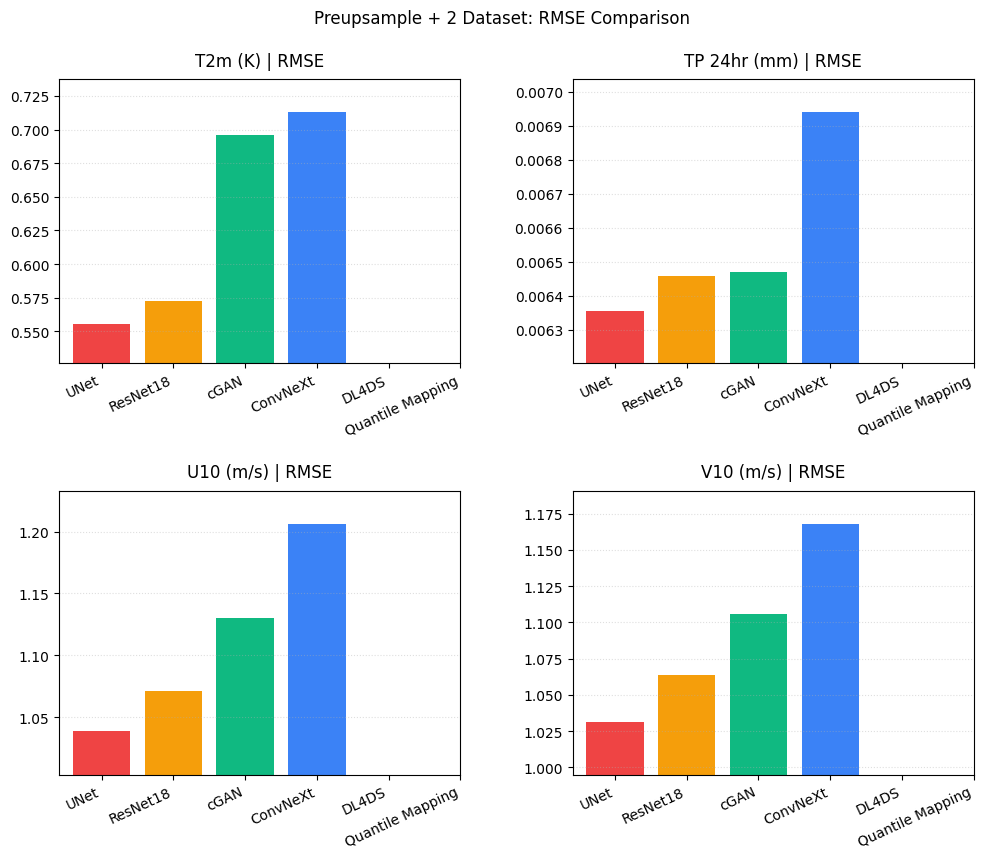

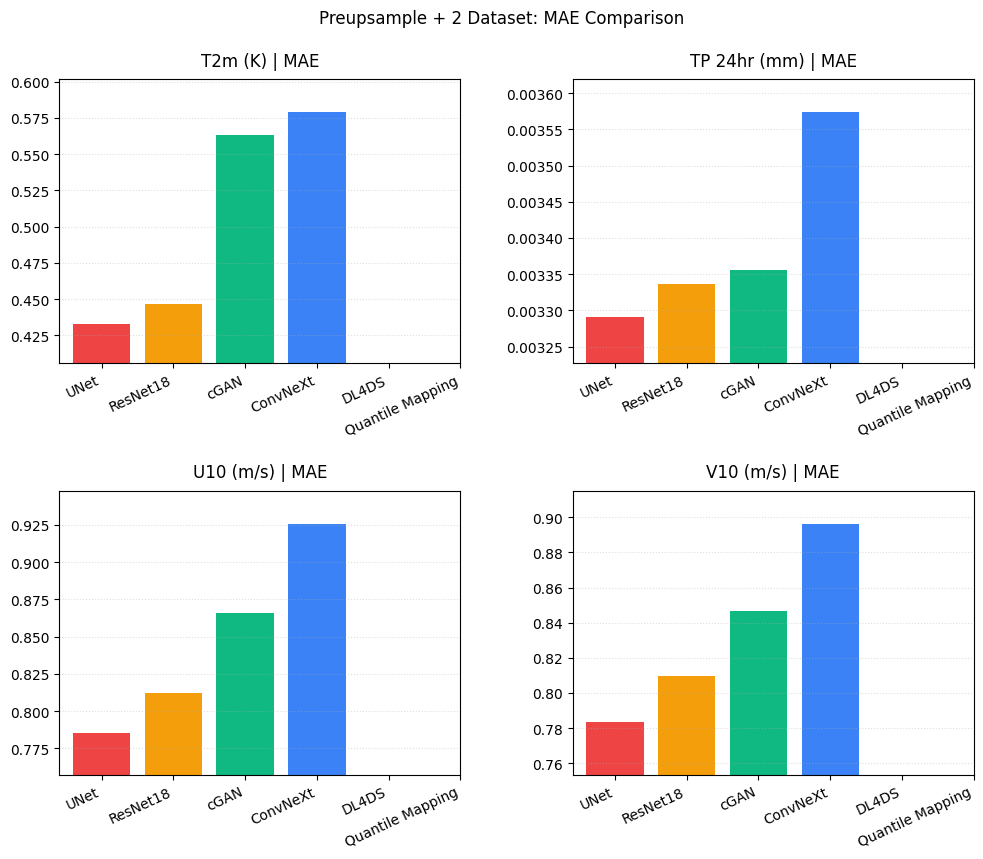

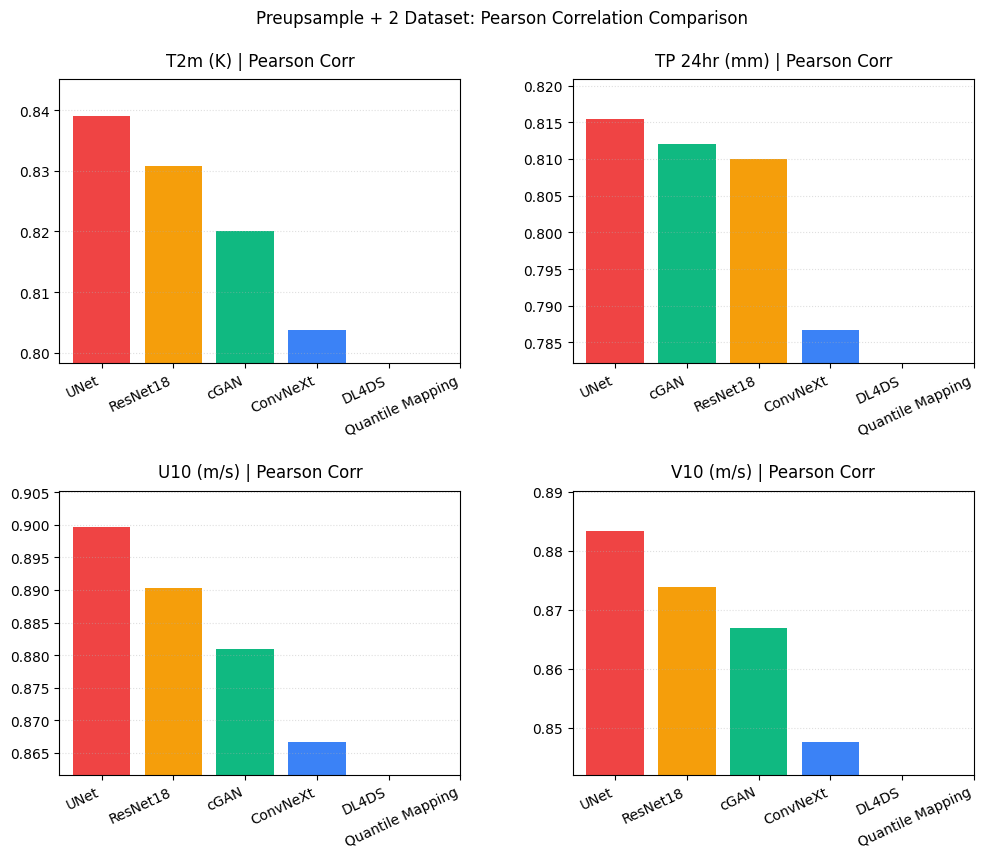

In [5]:
# --- Additional plots: RMSE, MAE, and Pearson correlation ---
# Reuse the same "preupsample + 2 dataset" selection as the MAE plot.
_dl4ds_qm_models_extra = {"DL4DS", "Quantile Mapping"}
extra_df = df[
    ((df["preupsample"] == "preupsample") | (df["model"].isin(_dl4ds_qm_models_extra)))
    & (df["dataset"] == "2 dataset")
    & (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
]

if extra_df.empty:
    raise ValueError("No rows for preupsample + 2 dataset in parsed_notebook_metrics.csv")

extra_df = extra_df.copy()
extra_df["model"] = extra_df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})
model_order_extra = ["ConvNeXt", "cGAN", "ResNet18", "UNet", "DL4DS", "Quantile Mapping"]
var_order_extra = ["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]
colors_extra = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6", "#ec4899"]
color_map_extra = dict(zip(model_order_extra, colors_extra))

def _plot_metric_grid(metric_col, metric_label, figure_title, better="lower"):
    agg_metric = (
        extra_df.groupby(["variable", "model"], as_index=False)
                .agg(mean_value=(metric_col, "mean"), std_value=(metric_col, "std"))
    )
    agg_metric["std_value"] = agg_metric["std_value"].fillna(0.0)

    fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.8))
    axes = axes.ravel()

    for ax, var_name in zip(axes, var_order_extra):
        sub = agg_metric[agg_metric["variable"] == var_name].set_index("model").reindex(model_order_extra)
        sort_ascending = better == "lower"
        sorted_models = (
            sub["mean_value"]
            .sort_values(ascending=sort_ascending, na_position="last")
            .index.tolist()
        )
        sub = sub.reindex(sorted_models)
        x = np.arange(len(sorted_models))
        mean_vals = sub["mean_value"].values
        std_vals = sub["std_value"].values

        ax.bar(x, mean_vals, capsize=3, color=[color_map_extra[m] for m in sorted_models])
        ax.set_xticks(x)
        ax.set_xticklabels(sorted_models, rotation=25, ha="right")
        ax.set_title(f"{var_name} | {metric_label}", pad=10)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

        y_min = np.nanmin(mean_vals - std_vals)
        y_max = np.nanmax(mean_vals + std_vals)
        pad = (y_max - y_min) * 0.15 if y_max > y_min else max(abs(y_max) * 0.1, 0.1)
        ax.set_ylim(y_min - pad, y_max + pad)

    fig.suptitle(figure_title, y=0.98)
    fig.subplots_adjust(hspace=0.45, wspace=0.28, top=0.9)
    plt.show()

_plot_metric_grid("rmse", "RMSE", "Preupsample + 2 Dataset: RMSE Comparison", better="lower")
_plot_metric_grid("mae", "MAE", "Preupsample + 2 Dataset: MAE Comparison", better="lower")
_plot_metric_grid("corr", "Pearson Corr", "Preupsample + 2 Dataset: Pearson Correlation Comparison", better="higher")

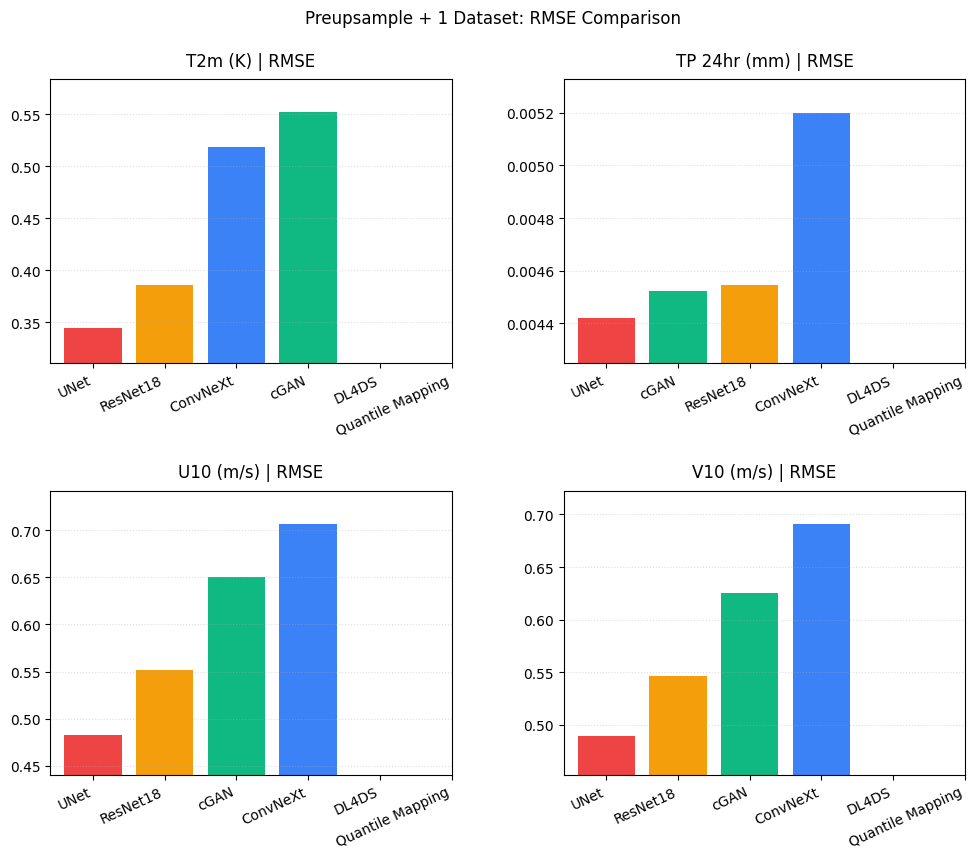

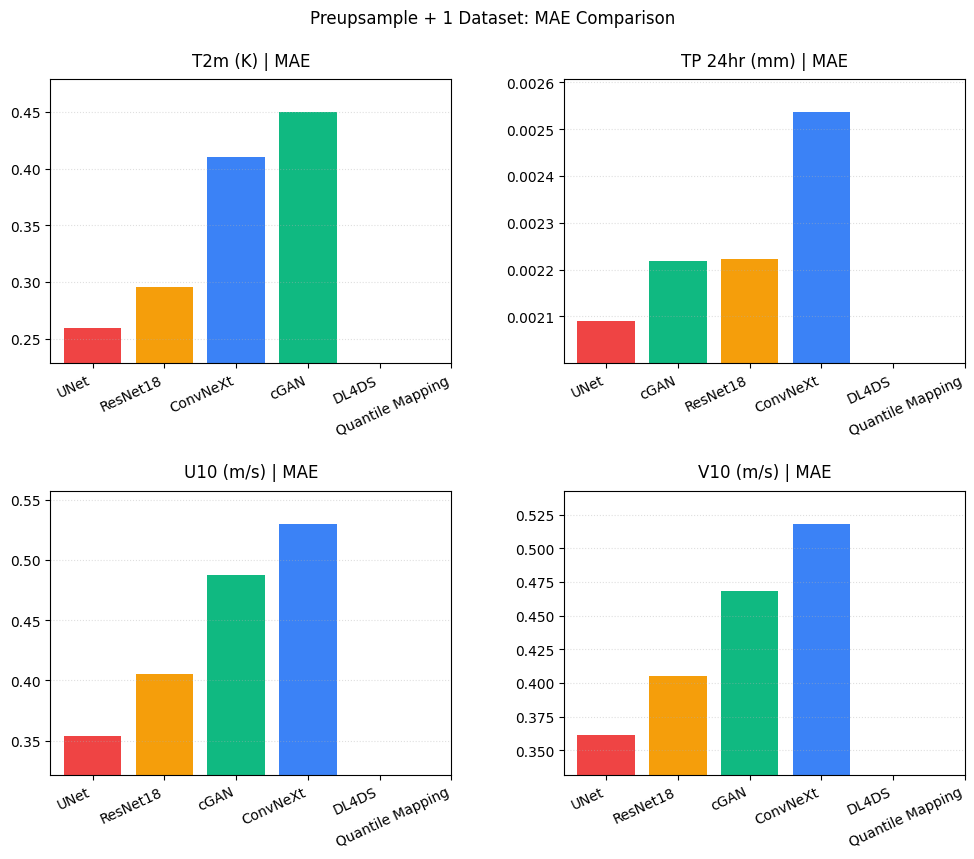

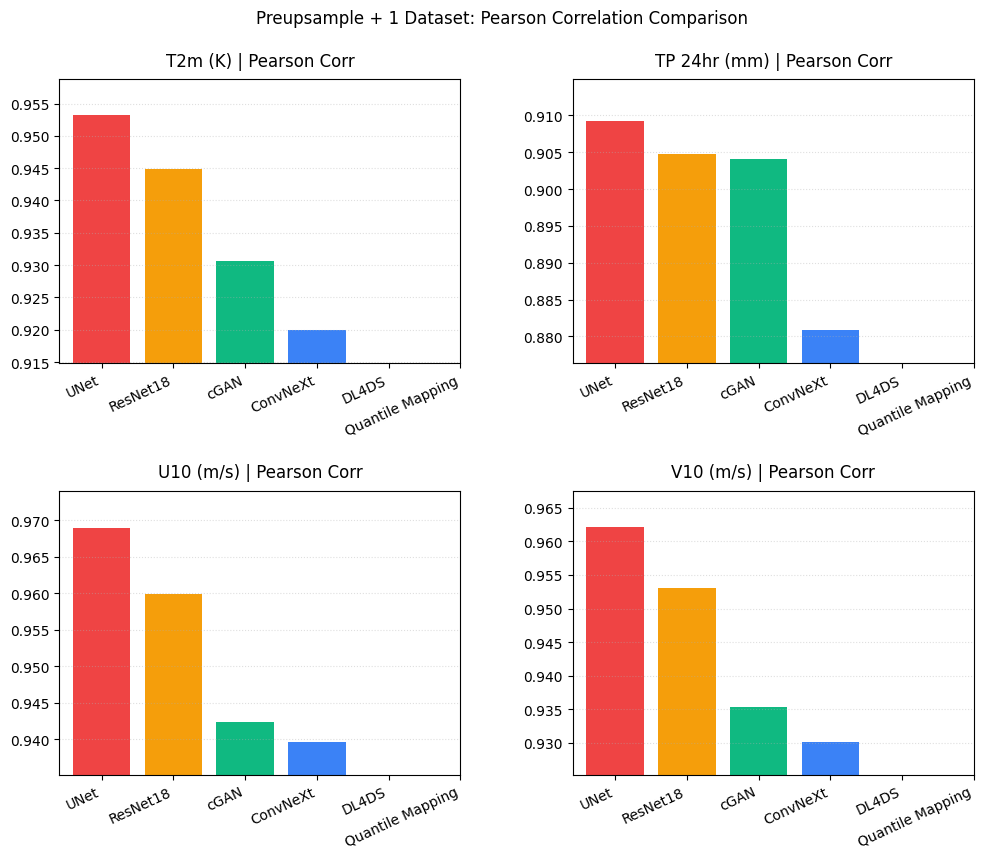

In [6]:
# --- Additional plots: RMSE and Pearson correlation ---
# Reuse the same "preupsample + 2 dataset" selection as the MAE plot.
_dl4ds_qm_models_extra = {"DL4DS", "Quantile Mapping"}
extra_df = df[
    ((df["preupsample"] == "preupsample") | (df["model"].isin(_dl4ds_qm_models_extra)))
    & (df["dataset"] == "1 dataset")
    & (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
]

if extra_df.empty:
    raise ValueError("No rows for preupsample + 1 dataset in parsed_notebook_metrics.csv")

extra_df = extra_df.copy()
extra_df["model"] = extra_df["model"].replace({"Unet": "UNet", "GAN": "cGAN"})
model_order_extra = ["ConvNeXt", "cGAN", "ResNet18", "UNet", "DL4DS", "Quantile Mapping"]
var_order_extra = ["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]
colors_extra = ["#3b82f6", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6", "#ec4899"]
color_map_extra = dict(zip(model_order_extra, colors_extra))

def _plot_metric_grid(metric_col, metric_label, figure_title, better="lower"):
    agg_metric = (
        extra_df.groupby(["variable", "model"], as_index=False)
                .agg(mean_value=(metric_col, "mean"), std_value=(metric_col, "std"))
    )
    agg_metric["std_value"] = agg_metric["std_value"].fillna(0.0)

    fig, axes = plt.subplots(2, 2, figsize=(11.8, 8.8))
    axes = axes.ravel()

    for ax, var_name in zip(axes, var_order_extra):
        sub = agg_metric[agg_metric["variable"] == var_name].set_index("model").reindex(model_order_extra)
        sort_ascending = better == "lower"
        sorted_models = (
            sub["mean_value"]
            .sort_values(ascending=sort_ascending, na_position="last")
            .index.tolist()
        )
        sub = sub.reindex(sorted_models)
        x = np.arange(len(sorted_models))
        mean_vals = sub["mean_value"].values
        std_vals = sub["std_value"].values

        ax.bar(x, mean_vals, capsize=3, color=[color_map_extra[m] for m in sorted_models])
        ax.set_xticks(x)
        ax.set_xticklabels(sorted_models, rotation=25, ha="right")
        ax.set_title(f"{var_name} | {metric_label}", pad=10)
        ax.grid(axis="y", linestyle=":", alpha=0.4)

        y_min = np.nanmin(mean_vals - std_vals)
        y_max = np.nanmax(mean_vals + std_vals)
        pad = (y_max - y_min) * 0.15 if y_max > y_min else max(abs(y_max) * 0.1, 0.1)
        ax.set_ylim(y_min - pad, y_max + pad)

    fig.suptitle(figure_title, y=0.98)
    fig.subplots_adjust(hspace=0.45, wspace=0.28, top=0.9)
    plt.show()

_plot_metric_grid("rmse", "RMSE", "Preupsample + 1 Dataset: RMSE Comparison", better="lower")
_plot_metric_grid("mae", "MAE", "Preupsample + 1 Dataset: MAE Comparison", better="lower")
_plot_metric_grid("corr", "Pearson Corr", "Preupsample + 1 Dataset: Pearson Correlation Comparison", better="higher")

,model,variable,RMSE % change,MAE % change,Corr delta
0,ConvNeXt,T2m (K),-30.51%,-32.38%,+0.1367
1,ConvNeXt,TP 24hr (mm),-27.03%,-29.54%,+0.2291
2,ConvNeXt,U10 (m/s),-34.64%,-35.03%,+0.1040
3,ConvNeXt,V10 (m/s),-34.67%,-34.97%,+0.1275
4,cGAN,T2m (K),-4.66%,-5.93%,+0.0021
5,cGAN,TP 24hr (mm),-0.83%,-1.48%,+0.0006
6,cGAN,U10 (m/s),-3.19%,-3.60%,+0.0067
7,cGAN,V10 (m/s),-1.81%,-2.12%,+0.0048
8,ResNet18,T2m (K),-22.40%,-24.62%,+0.0707
9,ResNet18,TP 24hr (mm),-16.24%,-17.61%,+0.0801


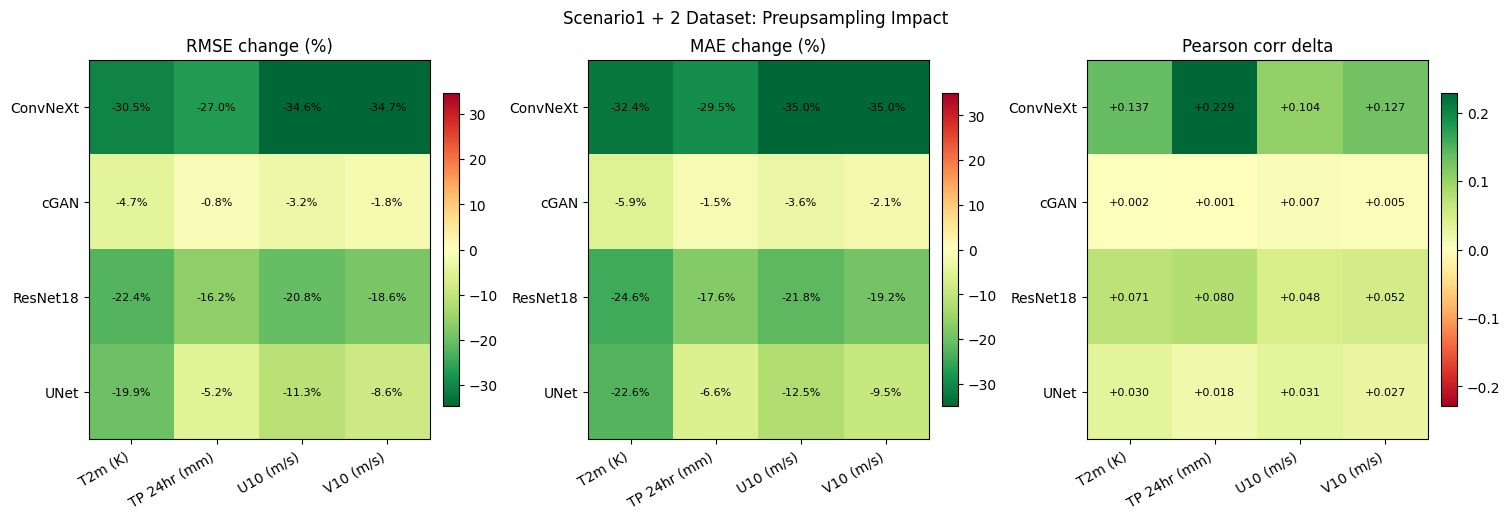

,model,mean_rmse_change,mean_mae_change,mean_corr_delta
0,ConvNeXt,-31.71%,-32.98%,+0.1493
2,ResNet18,-19.52%,-20.81%,+0.0626
3,UNet,-11.26%,-12.79%,+0.0264
1,cGAN,-2.62%,-3.28%,+0.0035


In [7]:
# --- Other analysis: impact of preupsampling vs no-preupsampling ---
# Compare paired model/variable averages for scenario1 + 2 dataset.
# Negative RMSE/MAE change means preupsampling reduced error; positive Corr change means improvement.
impact_df = df[
    (df["scenario"] == "scenario1")
    & (df["dataset"] == "2 dataset")
    & (df["preupsample"].isin(["no-preupsample", "preupsample"]))
    & (df["model"].isin(["ConvNeXt", "cGAN", "ResNet18", "UNet"]))
    & (df["variable"].isin(["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]))
].copy()

if impact_df.empty:
    raise ValueError("No paired rows for scenario1 + 2 dataset preupsample impact analysis")

impact_agg = (
    impact_df.groupby(["model", "variable", "preupsample"], as_index=False)
             .agg(rmse=("rmse", "mean"), mae=("mae", "mean"), corr=("corr", "mean"))
)

impact_wide = impact_agg.pivot(index=["model", "variable"], columns="preupsample", values=["rmse", "mae", "corr"])
impact_wide = impact_wide.dropna().reset_index()

for metric in ["rmse", "mae"]:
    impact_wide[f"{metric}_pct_change"] = (
        100 * (impact_wide[(metric, "preupsample")] - impact_wide[(metric, "no-preupsample")])
        / impact_wide[(metric, "no-preupsample")]
    )
impact_wide["corr_delta"] = impact_wide[("corr", "preupsample")] - impact_wide[("corr", "no-preupsample")]

impact_summary = impact_wide[[
    ("model", ""), ("variable", ""),
    ("rmse_pct_change", ""), ("mae_pct_change", ""), ("corr_delta", ""),
]].copy()
impact_summary.columns = ["model", "variable", "RMSE % change", "MAE % change", "Corr delta"]

model_order_impact = ["ConvNeXt", "cGAN", "ResNet18", "UNet"]
var_order_impact = ["T2m (K)", "TP 24hr (mm)", "U10 (m/s)", "V10 (m/s)"]
impact_summary["model"] = pd.Categorical(impact_summary["model"], categories=model_order_impact, ordered=True)
impact_summary["variable"] = pd.Categorical(impact_summary["variable"], categories=var_order_impact, ordered=True)
impact_summary = impact_summary.sort_values(["model", "variable"]).reset_index(drop=True)

display(
    impact_summary.style.format({
        "RMSE % change": "{:+.2f}%",
        "MAE % change": "{:+.2f}%",
        "Corr delta": "{:+.4f}",
    }).background_gradient(subset=["RMSE % change", "MAE % change"], cmap="RdYlGn_r")
      .background_gradient(subset=["Corr delta"], cmap="RdYlGn")
)

heatmap_metrics = [
    ("RMSE % change", "RMSE change (%)", "RdYlGn_r", "{:+.1f}%"),
    ("MAE % change", "MAE change (%)", "RdYlGn_r", "{:+.1f}%"),
    ("Corr delta", "Pearson corr delta", "RdYlGn", "{:+.3f}"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
for ax, (metric_col, title, cmap, fmt) in zip(axes, heatmap_metrics):
    mat = (
        impact_summary.pivot(index="model", columns="variable", values=metric_col)
                      .reindex(index=model_order_impact, columns=var_order_impact)
    )
    vals = mat.values.astype(float)
    vmax = np.nanmax(np.abs(vals))
    if np.isclose(vmax, 0):
        vmax = 1.0
    im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(title)
    ax.set_xticks(np.arange(len(var_order_impact)))
    ax.set_xticklabels(var_order_impact, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(model_order_impact)))
    ax.set_yticklabels(model_order_impact)

    for row_idx in range(vals.shape[0]):
        for col_idx in range(vals.shape[1]):
            ax.text(col_idx, row_idx, fmt.format(vals[row_idx, col_idx]), ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Scenario1 + 2 Dataset: Preupsampling Impact", y=1.05)
plt.show()

model_level_impact = (
    impact_summary.groupby("model", observed=True, as_index=False)
                  .agg(
                      mean_rmse_change=("RMSE % change", "mean"),
                      mean_mae_change=("MAE % change", "mean"),
                      mean_corr_delta=("Corr delta", "mean"),
                  )
)
model_level_impact.sort_values("mean_rmse_change").style.format({
    "mean_rmse_change": "{:+.2f}%",
    "mean_mae_change": "{:+.2f}%",
    "mean_corr_delta": "{:+.4f}",
})